In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import mglearn
import tensorflow as tf

In [5]:
pip install tensorflow

   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 1.0/351.2 MB 5.8 MB/s eta 0:01:01
   ---------------------------------------- 2.1/351.2 MB 5.1 MB/s eta 0:01:09
   ---------------------------------------- 3.1/351.2 MB 4.9 MB/s eta 0:01:11
   ---------------------------------------- 3.9/351.2 MB 4.9 MB/s eta 0:01:12
    --------------------------------------- 4.5/351.2 MB 4.5 MB/s eta 0:01:17
    --------------------------------------- 5.2/351.2 MB 4.4 MB/s eta 0:01:20
    --------------------------------------- 6.0/351.2 MB 4.3 MB/s eta 0:01:21
    --------------------------------------- 6.6/351.2 MB 4.2 MB/s eta 0:01:23
    --------------------------------------- 6.6/351.2 MB 4.2 MB/s eta 0:01:23
    --------------------------------------- 6.6/351.2 MB 4.2 MB/s eta 0:01:23
    --------------------------------------- 6.6/351.2 MB 4.2 MB/s eta 0:01:23
    --------------------------------------- 6.6/351.2 MB 4.2 MB/s eta 0

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.35.1 which is incompatible.


In [7]:
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Dense

In [9]:
np.random.seed(180)
tf.random.set_seed(180)

In [10]:
people=fetch_lfw_people(min_faces_per_person=20,resize=0.7)
print(people.data.shape)
print(people.target.shape)
image_shape=people.images[0].shape

(3023, 5655)
(3023,)


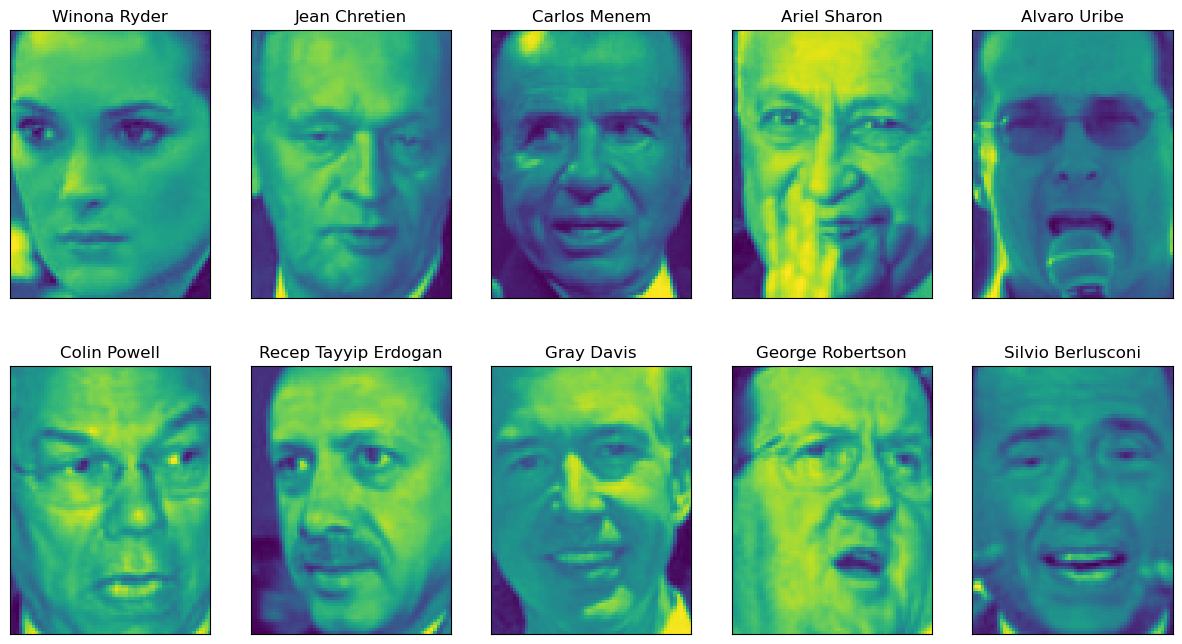

In [16]:
fix,axes=plt.subplots(2,5,figsize=(15,8),subplot_kw={'xticks':(),'yticks':()})
for target,image,ax in zip(people.target,people.images,axes.ravel()):
    ax.imshow(image) 
    ax.set_title(people.target_names[target])


In [19]:
X_train,X_test,y_train,y_test=train_test_split(
    people.data,
    people.target,
    test_size=0.2,
    random_state=20)
y_train=y_train.astype(int)
y_test=y_test.astype(int)
batch_size=len(X_train)
print(X_train.shape,y_train.shape,y_test.shape)
print("people.images.shape:{}".format(people.images.shape))
print("Number of classes:{}".format(len(people.target_names)))      

(2418, 5655) (2418,) (605,)
people.images.shape:(3023, 87, 65)
Number of classes:62


In [28]:
counts=np.bincount(people.target)
for i,(count,name) in enumerate(
    zip(counts,people.target_names)):
    print("{0:25}{1:3}".format(name,count),end="")
if(i+1)%3==0:
    print()

Alejandro Toledo          39Alvaro Uribe              35Amelie Mauresmo           21Andre Agassi              36Angelina Jolie            20Ariel Sharon              77Arnold Schwarzenegger     42Atal Bihari Vajpayee      24Bill Clinton              29Carlos Menem              21Colin Powell             236David Beckham             31Donald Rumsfeld          121George Robertson          22George W Bush            530Gerhard Schroeder        109Gloria Macapagal Arroyo   44Gray Davis                26Guillermo Coria           30Hamid Karzai              22Hans Blix                 39Hugo Chavez               71Igor Ivanov               20Jack Straw                28Jacques Chirac            52Jean Chretien             55Jennifer Aniston          21Jennifer Capriati         42Jennifer Lopez            21Jeremy Greenstock         24Jiang Zemin               20John Ashcroft             53John Negroponte           31Jose Maria Aznar          23Juan Carlos Ferrero       28Junichiro Koizumi   

In [29]:
mask = np.zeros(
    people.target.shape,
    dtype=np.bool_
)
for target in np.unique(people.target):
    mask[
        np.where(people.target==target)[0][:50]
    ]=True
X_people=people.data[mask]
y_people=people.target[mask]
X_people=X_people/255.0

In [30]:
X_train,X_test,y_train,y_test=train_test_split(
    X_people,
    y_people,
    stratify=y_people,
    random_state=0
)
knn=KNeighborsClassifier(
    n_neighbors=1
)
knn.fit(
    X_train,
    y_train
)
print(
    "Test set score of 1-nn:{:.2f}".format(
        knn.score(
            X_test,
            y_test
        )
    )
)

C:\Users\cplab04\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\cplab04\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


ValueError: Found input variables with inconsistent numbers of samples: [516, 605]

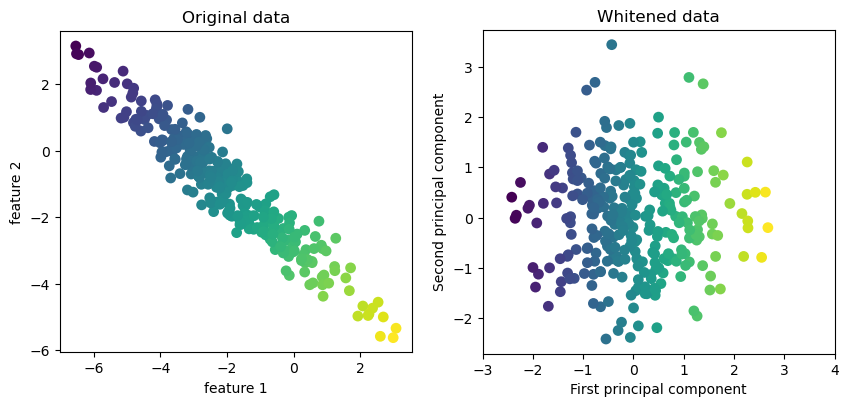

In [31]:
mglearn.plots.plot_pca_whitening()
plt.show()

In [33]:
pca=PCA(
    n_components=100,
    whiten=True,
    random_state=0
).fit(X_train)
X_train_pca=pca.transform(X_train)
X_test_pca=pca.transform(X_test)
print(
    "X_train_pca.shape:{}".format(
        X_train_pca.shape
    )
)
knn=KNeighborsClassifier(
    n_neighbors=1
)
knn.fit(
    X_train_pca,
    y_train
)
print(
    "Test set accuracy:{:.2f}".format(
        knn.score(
            X_test_pca,
            y_test
        )
    )
)
print(
    "pca.components_shape:{}".format(
        pca.components_.shape))

X_train_pca.shape:(1547, 100)


ValueError: Found input variables with inconsistent numbers of samples: [516, 605]

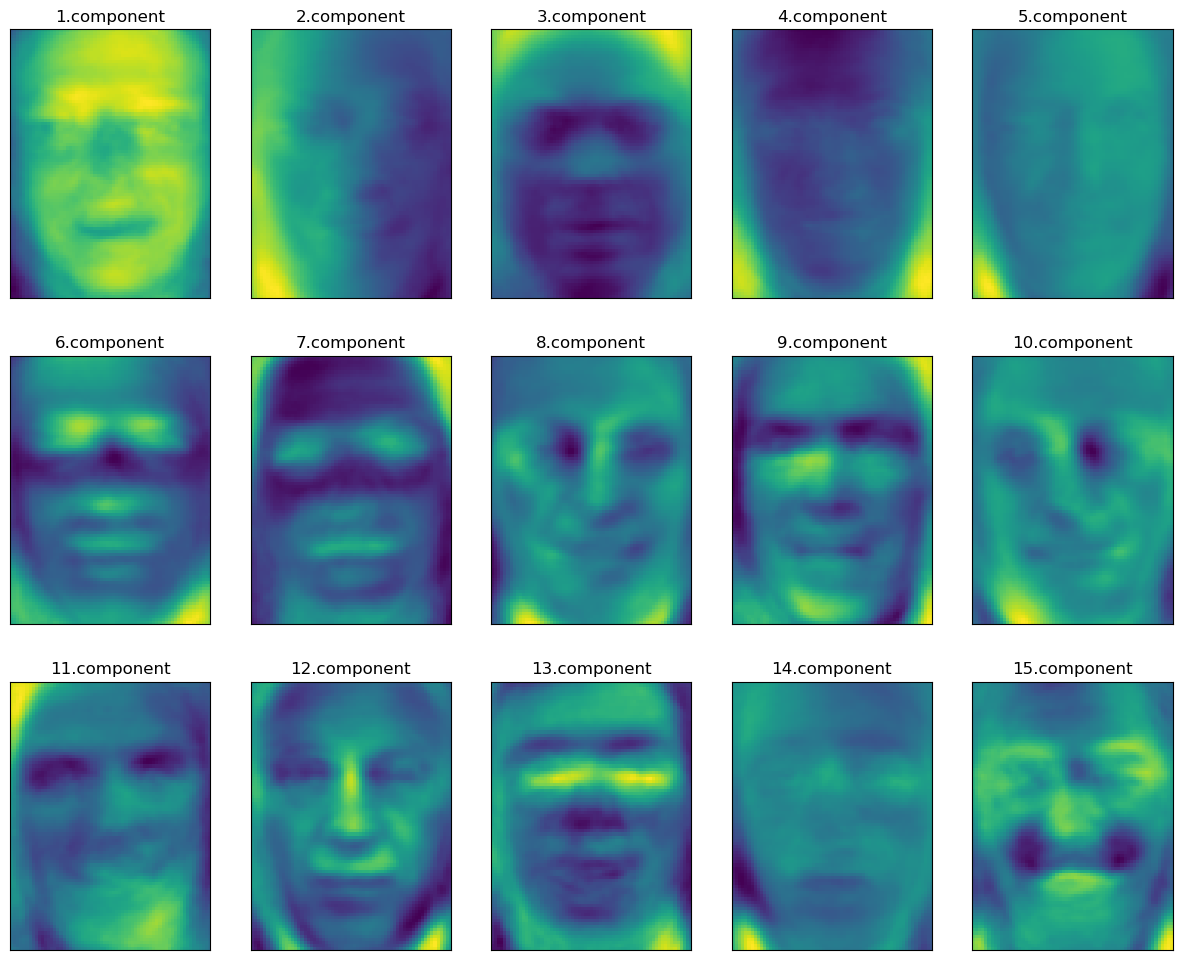

In [41]:
fix,axes=plt.subplots(
    3,
    5,
    figsize=(15,12),
    subplot_kw={'xticks':(),'yticks':()}
)
for i,(component,ax) in enumerate(
    zip(pca.components_,axes.ravel())):
    ax.imshow(
        component.reshape(image_shape),
        cmap='viridis'
    )
    ax.set_title(
    "{}.component".format(i+1)
    )
plt.show() 

In [42]:
scaler=MinMaxScaler()
X_train_scaled=scaler.fit_transform(
    X_train_pca
)
X_train_scaled=scaler.transform(
    X_test_pca
)

model=Sequential([
input(shape=(100,)),
Dense(300,activation='relu'),
Dense(100,activation='relu'),
Dense(len(np.unique(y_train)),activation='softmax')])



In [44]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(10, activation='softmax')
])

C:\Users\cplab04\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [45]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [46]:
history=model.fit(X_train_scaled,y_train,batch_size=50,epochs=20,shuffle=False,verbose=1)

ValueError: Data cardinality is ambiguous. Make sure all arrays contain the same number of samples.'x' sizes: 605
'y' sizes: 1547


In [47]:
loss,accuracy=model.evaluate(X_test_scaled,y_test,verbose=1)
print("Test Loss:",loss)
print("Test Accuracy:",accuracy)

NameError: name 'X_test_scaled' is not defined